In [ ]:
import numpy as np
import pandas as pd

# `Trascription`

In [ ]:
dna = 'AAAACCCGGT'
complement = []
for i in range(len(dna)):
  if dna[i] == 'A':
    complement.append('T')
  elif dna[i] == 'T':
    complement.append('A')
  elif dna[i] == 'C':
    complement.append('G')
  elif dna[i] == 'G':
    complement.append('C')

  print(complement)


['T']
['T', 'T']
['T', 'T', 'T']
['T', 'T', 'T', 'T']
['T', 'T', 'T', 'T', 'G']
['T', 'T', 'T', 'T', 'G', 'G']
['T', 'T', 'T', 'T', 'G', 'G', 'G']
['T', 'T', 'T', 'T', 'G', 'G', 'G', 'C']
['T', 'T', 'T', 'T', 'G', 'G', 'G', 'C', 'C']
['T', 'T', 'T', 'T', 'G', 'G', 'G', 'C', 'C', 'A']


In [ ]:
map = {'A':'T', 'G':'C', 'C':'G', 'T':'A'}
complement1 = [map[base] for base in dna]
print(complement1)

['T', 'T', 'T', 'T', 'G', 'G', 'G', 'C', 'C', 'A']


# **Nucleotide_count**

In [ ]:
dna = 'AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGC'
count_a = dna.count('A')
count_c = dna.count('C')
count_g = dna.count('G')
count_t = dna.count('T')
print(count_a, count_c, count_g, count_t)


20 12 17 21


In [ ]:
for i in range(2,10):
  print(i)

2
3
4
5
6
7
8
9


# fibonacci

```
fn-1 * k.fn-2
Rabbits take two months to mature and one months give raise to k pairs for mature

```



In [ ]:
#
def rabbits(n, k):
    # Step 1: initial months
    a = 1  # Month 1
    b = 1  # Month 2

    # Step 2: build from month 3 to n
    for i in range(3, n + 1):
        # Step 3: compute current month
        c = b + k * a

        # Step 4: shift forward
        a = b
        b = c

    # Step 5: answer is last computed month
    return b

rabbits(5, 3)


19

# **Max_GC_content**

In [ ]:
def parse_fasta(filename):
    with open(filename, 'r') as f:
      data = f.read()
    # remove the first space [1]
    # strip removes spaces
    #split divides
    entries = data.strip().split('>')[1:]
    sequences = {}
    for entry in entries:
      lines = entry.splitlines()
      label= lines[0].strip()
      seq = ''.join(lines[1:]).strip()
      sequences[label] = seq
    return sequences

def gc_count(seqs):

  gc_content = (seqs.count('G') + seqs.count('C')) /len(seqs)
  return (gc_content * 100)


def max_gc(filename):
  fasta = parse_fasta(filename)
  max_gc = 0
  max_id = None
  for seq_id, seq in fasta.items():
    gc = gc_count(seq)
    if gc > max_gc:
      max_gc = gc
      max_id = seq_id

  return max_id, max_gc



In [ ]:
rosaid ,maximum_gc = max_gc('/content/rosalind_gc (4).txt')
print(rosaid)
print(f"{maximum_gc:.6f}")


Rosalind_9377
53.536453


# Finding mofits

In [ ]:
dna='GATATATGCATATACTT'
mofit = 'ATAT'

In [ ]:

def find_mofit(filename):
  with open(filename, 'r') as f:
    data = f.read()
  lines = data.strip().splitlines()
  dna = lines[0].strip()
  mofit = lines[1].strip()
  mofit_loc = []
  mofit_len = len(mofit)
  for j in range((len(dna)- mofit_len) +1):
    if dna[j:j+mofit_len] == mofit:
      mofit_loc.append(j+1)
  return mofit_loc


In [ ]:
mofit_pos = find_mofit('/content/rosalind_subs (2).txt')


# **Finding mutations**


In [ ]:
dna1 = 'GAGCCTACTAACGGGAT'
dna2 = 'CATCGTAATGACGGCCT'
mutation_no = 0
mutation_po = []
for i in range(len(dna1)):
    if dna1[i] == dna2[i]:
      mutation_no +=1
      mutation_po.append(i)
print(mutation_no, mutation_po)

10 [1, 3, 5, 6, 8, 10, 11, 12, 13, 16]


In [1]:
def parse_data(filename):
  with open(filename, 'r') as f:
    data = f.read()
  dna = data.splitlines()
  dna1= dna[0]
  dna2 = dna[1]
  return dna1, dna2

# mutation finder
def mutation_finder(dna1,dna2):
  mutation_no = 0
  # flag error
  if len(dna1) != len(dna2):
    raise MyError('Dna lengths are different')
  # mutation finder
  for i in range(len(dna1)):
    if dna1[i] != dna2[i]:
      mutation_no +=1
  return mutation_no


In [2]:
dna1, dna2 = parse_data('/content/rosalind_hamm (1).txt')
mutation_no = mutation_finder( dna1, dna2)
print(mutation_no)

471


#Mendel Inheritance

MENDEL INHERITANCE

we are using probabilities for this.
we have a population(T) that has (k)
  individuals are homozygous dominant for a factor, (m)
 are heterozygous, and (n)
 are homozygous recessive.

 We are tasked to find the probability  of **PHYNOTYPICALLY DOMINATE** offsprings form such a populations?



```
our approach
1 - P(recessive)

Offsprings with a recessive allele can only be gotten from
Parents	Chance of aa child
aa × aa	1
aa × Aa	1/2
Aa × Aa	1/4

Probability of picking parents

We pick without replacement, so:
🔴 aa × aa
(n/T) × ((n-1)/(T-1))

🔴 aa × Aa (both orders!)
2 × (n/T) × (m/(T-1)) then * 1/2

🟢 Aa × Aa
(m/T) × ((m-1)/(T-1)) then * 1/4


so recessive is
P(recessive) =
(n/T)*((n-1)/(T-1))
+ 2*(n/T)*(m/(T-1))*(1/2)
+ (m/T)*((m-1)/(T-1))*(1/4)

so our dominant is
P(dominant) = 1 - P(recessive)
```




In [ ]:
# mendel
def mendel_first_law(k,m,n):
  T = k + m + n
  # parents probability of producing offsprings of recessive_aa
  p_aa_aa = (n/T) * ((n-1)/(T-1))
  p_aa_Aa = 2*(n/T) * (m/(T-1)) * 0.5
  p_Aa_Aa = (m/T) * ((m-1)/(T-1)) * 0.25

  # total probability of parents producing recessive offsprings
  prob_recessive = p_aa_aa + p_aa_Aa + p_Aa_Aa
   # total probability of parents producing dominate offsprings
  prob_dominant = 1 - prob_recessive

  return prob_dominant

prob = mendel_first_law(27, 25, 29)
print(prob)

0.7396604938271605


# **Consensus sequences**

---


>  Matrix is used
```

DNA Strings
A T C C A G C T
G G G C A A C T
A T G G A T C T
A A G C A A C C
T T G G A A C T
A T G C C A T T
A T G G C A C T

A profile matrix is created showing the count of ATCG bases in the Dna string ie count of base A at position 1
Profile
A   5 1 0 0 5 5 0 0
C   0 0 1 4 2 0 6 1
G   1 1 6 3 0 1 0 0
T   1 5 0 0 0 1 1 6

Consensus	A T G C A A C T

```

```
# How the python code works  
for the profile matrices

sequences = ["ATC", "AAC", "GTC"]
n = 3
profile = {
    'A': [0,0,0],
    'C': [0,0,0],
    'G': [0,0,0],
    'T': [0,0,0]
}


Go string by string:

"ATC"
i=0 → 'A' → profile['A'][0] += 1 → [1,0,0]
i=1 → 'T' → profile['T'][1] += 1 → [0,1,0]
i=2 → 'C' → profile['C'][2] += 1 → [0,0,1]
"AAC"
i=0 → 'A' → profile['A'][0] += 1 → [2,0,0]
i=1 → 'A' → profile['A'][1] += 1 → [2,1,0]
i=2 → 'C' → profile['C'][2] += 1 → [0,0,2]
"GTC"
i=0 → 'G' → profile['G'][0] += 1 → [0,0,0] → [1,0,0]
i=1 → 'T' → profile['T'][1] += 1 → [0,2,0]
i=2 → 'C' → profile['C'][2] += 1 → [0,0,3]


output

profile = {
    'A': [2,1,0],
    'C': [0,0,3],
    'G': [1,0,0],
    'T': [0,2,0]
}
```
To get our consensus : for every position which base has the highest count. It looks at all bases at that position and finds the max






In [ ]:
def data_parse(filename):
  with open(filename , 'r') as f:
    data = f.read()
  reads = data.strip().split('>')[1:]
  sequences = []
  for entries in reads:
    lines = entries.splitlines()
    seq = ''.join(l.strip() for l in lines[1:])
    sequences.append(seq)
  return sequences

def profile_matrices(seq):
  seq_len = len(seq[0])
  #profile outline
  profile = {
        'A':[0]*seq_len,
        'T':[0]*seq_len,
        'C':[0]*seq_len,
        'G':[0]*seq_len
    }
  #profile_creation
  for dna in seq:
    for i in range(len(dna)):
      profile[dna[i]][i] += 1

  #consensus creation


  consensus = ''
  for j in range(seq_len):
    max_count = 0
    max_base = ''
    for base in 'ATGC':
      if profile[base][j] > max_count:
        max_count = profile[base][j]
        max_base = base
    consensus += max_base

  return consensus, profile






In [ ]:
seq = data_parse('/content/rosalind_cons (1).txt')
print(seq)


['TTCGGACGATGGCTTTAATTGTCAGCGTTTTTAGCATGATCGGCAACTGGAGACCGACATGACATAAAATGACGGTCCCTACCAGCAGGGGCTTGATGAGGGGCTTTATTGTTGTTATTTGTAGAGATATGGCTACATACGAGTTATGCGACCCAACGAGCCCTAAAGGCTGCGTTTTTGGTTAATCATTCGGTCTAATGGGCAACTTCATGTTCAATTTTGGCTGTAGCTCCGTATCCGGAAGTGCTTGAGTAAGTAATCTGGATAACGCAAGGCACCTTGCGAAGATAGAATGCGTTGCCTTGATTTATATTATTTTGGGATCGTTCTATCTGCAGTTCATCTTCGGCCCCTAGACATTCCCACCCCATGAGGTTTCGCACAGACTTTTGCAACCACTTTAACTCCCCTAGGATCACTCGGGCGGAGGGTAACTGTAATGCCAATATGCTTATATGACAGGATTGCGCTGGGGGCCTTTGGGTTCTCCGCAATTATGTATATGGCGCCTTCCATGATTGTGTCTATCAATCGGGCATGTCGACAGCCACACCTGCTACTAGCCTATAAGCTGGTAACTCCGTCGACGATGACTCAATTCTTGGCATGCTTAGATTCGCATTACACTTTATCACGGAAGCTGGAACCCTGTCCCGGTGGGACCACTCGCGGGATGAGCCACAGACATGATACACATGCTAACCAACAGCTATGCAAATGGAGTCATCCCAAATTAGCAAGACCAGCCACAGGAGCCCTGTGCCCACGTAGAGTGTTACGAAATTCGACAGCCGTATGAAAGAAGAATTGAAAGTACAGCGCTTTCGCGTGCACACCGATATCACCCTCATCCGAGGTTAGCGACGCGATTCTCACCCCTCATTCGATCCTCACTGGCAGTTGATCTGAGCCTCTTTGGAAGAGCCCTACAGCAATTGTAGGCCTCGAGTCAAGTCTGTAATTTGGCAAGGCAAGTATCATTCCCAGCGT', 'GCAA

In [ ]:
consensus, profile = profile_matrices(seq)

print (profile)

GGCTGTCATATGCGTAAAGTTATATGAAACGTTATCTTAGTAAGCTGTTGGGCCTGACGAGTGAGAAAGAACCGTTTAAAAGAGGGCGTATAGAGTATAGAGTTGAAGTCGGAACTTGAAGAAATAAAATATGTATAGCTGATTGCGTAGGTGCTAAAAATTCGTACCAGATCCTGTTACAAGATTAATCCGGTCAAAAGTCGAATATCGGGCTTGATAGCCGATAGCTGCTCGAAACTACTATCTCTAAAACAATATGGGATTATGAAATAAGGCACAGTGGTAATCTAACTTAAGAACAATATCTTATTTGTAAATTGGGTACTAGGTATGTTCTAGTAATCTACTAAACGTAGACGTTGACAGGATAGTGAGAATTTAAGTATTCAATGCAGGAGATTACGGATACCTATAATAATGTGGTCCGGAAATCTGAGTAATGAAAATGTTCTTTAATGACCTCATATACTCGGTGTAATGTGAGTACTCAGGGTTTTTCCATTTGTTGTCGGGAATATTGCTAAAACGAGATTGAAGCGACCTACAGGGAGCCTTAACAAAACTACCTAAGAAGGCTGAGCTAAAAAAAATAAGTCGGTCCATGTCATGAGTTAGATTATACATTTCAGGCACACGGACTATGAAAGCGTTAAACATGGGCTATGGCAGGCGCGTATACAATGATCCTAAAGCTCGAGATAATCATAGGTCAGATAAAAGCAGTGATCGCGCGATCGATCATATGGCCACTGGACTGTTAAAGTCATTATGCTTGTATTGTCAATAGATTATCGGAAATATAAAAGTTTGAAAATACAATTATAGTGCCTTTAAATCAAGATCGTTGAGCGACTAGGAAATCAATCCGGCCAATGCTAATACTTTGGGCCAGAATGCCTGATAATAACCCAAGGTACCCTAAAGCTGTGCTCTTATTCGAGACCCCGTTACTACTTGGCAAAATTGCCAGTGACGGTAGAAGACAACAGT
{'A': [1,

In [ ]:
print( consensus)
for base in 'ACGT':
    print(f"{base}: {' '.join(map(str, profile[base]))}")

GGCTGTCATATGCGTAAAGTTATATGAAACGTTATCTTAGTAAGCTGTTGGGCCTGACGAGTGAGAAAGAACCGTTTAAAAGAGGGCGTATAGAGTATAGAGTTGAAGTCGGAACTTGAAGAAATAAAATATGTATAGCTGATTGCGTAGGTGCTAAAAATTCGTACCAGATCCTGTTACAAGATTAATCCGGTCAAAAGTCGAATATCGGGCTTGATAGCCGATAGCTGCTCGAAACTACTATCTCTAAAACAATATGGGATTATGAAATAAGGCACAGTGGTAATCTAACTTAAGAACAATATCTTATTTGTAAATTGGGTACTAGGTATGTTCTAGTAATCTACTAAACGTAGACGTTGACAGGATAGTGAGAATTTAAGTATTCAATGCAGGAGATTACGGATACCTATAATAATGTGGTCCGGAAATCTGAGTAATGAAAATGTTCTTTAATGACCTCATATACTCGGTGTAATGTGAGTACTCAGGGTTTTTCCATTTGTTGTCGGGAATATTGCTAAAACGAGATTGAAGCGACCTACAGGGAGCCTTAACAAAACTACCTAAGAAGGCTGAGCTAAAAAAAATAAGTCGGTCCATGTCATGAGTTAGATTATACATTTCAGGCACACGGACTATGAAAGCGTTAAACATGGGCTATGGCAGGCGCGTATACAATGATCCTAAAGCTCGAGATAATCATAGGTCAGATAAAAGCAGTGATCGCGCGATCGATCATATGGCCACTGGACTGTTAAAGTCATTATGCTTGTATTGTCAATAGATTATCGGAAATATAAAAGTTTGAAAATACAATTATAGTGCCTTTAAATCAAGATCGTTGAGCGACTAGGAAATCAATCCGGCCAATGCTAATACTTTGGGCCAGAATGCCTGATAATAACCCAAGGTACCCTAAAGCTGTGCTCTTATTCGAGACCCCGTTACTACTTGGCAAAATTGCCAGTGACGGTAGAAGACAACAGT
A: 1 1 2 

Traslation

In [ ]:
def codon_map(filename):
  with open(filename, 'r') as f:
    data = f.read()
  codon_dict = {}
  tokens = data.split()
  i =0
  while i < len(tokens):
    codon = tokens[i]
    amino_acids = tokens[i+1]
    codon_dict[codon] = amino_acids
    i+=2


  return codon_dict

In [ ]:
codon_amino_map = codon_map('/content/rna_table.txt')
print(codon_amino_map)

{'UUU': 'F', 'CUU': 'L', 'AUU': 'I', 'GUU': 'V', 'UUC': 'F', 'CUC': 'L', 'AUC': 'I', 'GUC': 'V', 'UUA': 'L', 'CUA': 'L', 'AUA': 'I', 'GUA': 'V', 'UUG': 'L', 'CUG': 'L', 'AUG': 'M', 'GUG': 'V', 'UCU': 'S', 'CCU': 'P', 'ACU': 'T', 'GCU': 'A', 'UCC': 'S', 'CCC': 'P', 'ACC': 'T', 'GCC': 'A', 'UCA': 'S', 'CCA': 'P', 'ACA': 'T', 'GCA': 'A', 'UCG': 'S', 'CCG': 'P', 'ACG': 'T', 'GCG': 'A', 'UAU': 'Y', 'CAU': 'H', 'AAU': 'N', 'GAU': 'D', 'UAC': 'Y', 'CAC': 'H', 'AAC': 'N', 'GAC': 'D', 'UAA': 'Stop', 'CAA': 'Q', 'AAA': 'K', 'GAA': 'E', 'UAG': 'Stop', 'CAG': 'Q', 'AAG': 'K', 'GAG': 'E', 'UGU': 'C', 'CGU': 'R', 'AGU': 'S', 'GGU': 'G', 'UGC': 'C', 'CGC': 'R', 'AGC': 'S', 'GGC': 'G', 'UGA': 'Stop', 'CGA': 'R', 'AGA': 'R', 'GGA': 'G', 'UGG': 'W', 'CGG': 'R', 'AGG': 'R', 'GGG': 'G'}


In [ ]:
def data_parse(filename):
  with open(filename, 'r') as f:
    data = f.read()
  rna = data.strip()
  return rna

def traslation( map, rna):



In [ ]:
rna = data_parse('/content/rosalind_prot.txt')
peptide = traslation(codon_amino_map, rna)

# **Fibonacci mortility**



where Age 1 = newborns
Only rabbits of age 2 and 3 reproduce
Rabbits die after age 3
Each mature pair produces 1 new pair
n = number of months
m = lifespan of rabbits (in months)

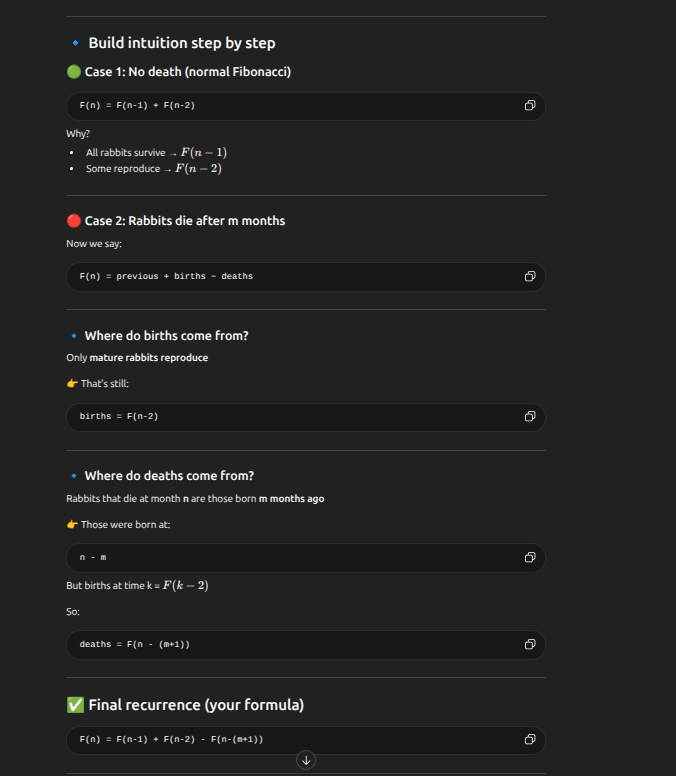

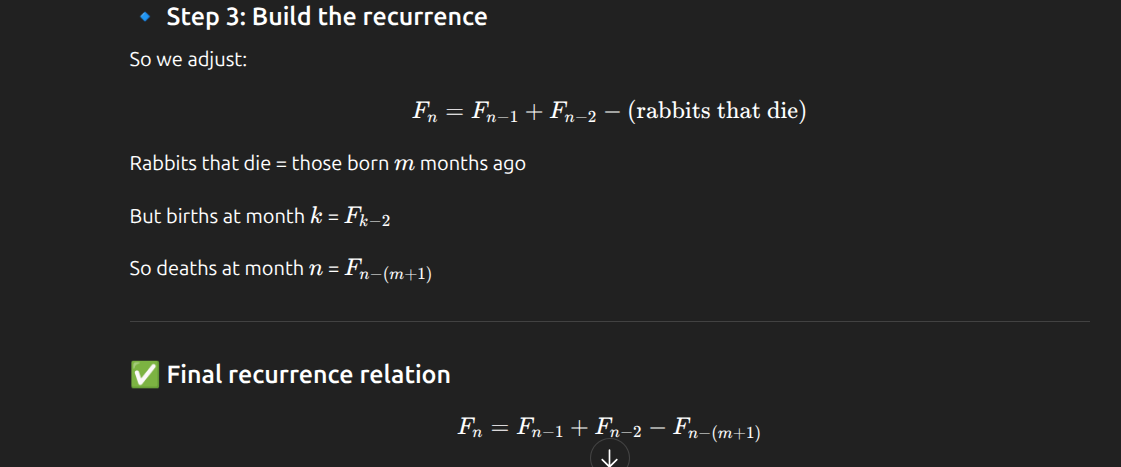

In [ ]:
def fiba_mortality(n, m):
  f = [0]*(n+1)
  f[1], f[2] = 1,1

  for i in range(3, n+1):
    f[i] = f[i-1] + f[i-2]
    if i == m+1:
      f[i] -= f[i] - 1
    elif i > m:
      f[i] = f[i] - f[i - (m+1)]
  return f


In [ ]:
total_per_months = fiba_mortality(6, 3)
print(total_per_months)

[0, 1, 1, 2, 1, 2, 2]


# **Overlap graph**


In [ ]:
def data_parse(filename):
  with open(filename, 'r') as f:
    data = f.read()
  reads = data.strip().split('>')[1:]
  return reads


In [ ]:
def overlap_finder(reads, kmer):
  sequences = {}
  for seqs in reads:
    seq = seqs.splitlines()
    label = seq[0]
    sequence = ''.join(seq[1:])
    sequences[label] = sequence
  overlap = []

  for s_label,  s_sequence in sequences.items():
    for t_label , t_sequence in sequences.items():
      if s_label != t_label:
        if s_sequence[-kmer:] == t_sequence[:kmer]:
          overlap.append((s_label, t_label))

  return overlap





In [ ]:
reads = data_parse('/content/rosalind_grph (2).txt')
overlap = overlap_finder(reads,3)

for a,b in overlap:
  with
  print(a,b)

Rosalind_7357 Rosalind_5492
Rosalind_7357 Rosalind_9845
Rosalind_7357 Rosalind_6815
Rosalind_7357 Rosalind_0336
Rosalind_2730 Rosalind_0778
Rosalind_1729 Rosalind_0778
Rosalind_3623 Rosalind_7395
Rosalind_3431 Rosalind_0130
Rosalind_3431 Rosalind_2170
Rosalind_4508 Rosalind_8321
Rosalind_4508 Rosalind_6754
Rosalind_0545 Rosalind_7600
Rosalind_9456 Rosalind_9673
Rosalind_1955 Rosalind_7921
Rosalind_8167 Rosalind_9310
Rosalind_8167 Rosalind_5972
Rosalind_9221 Rosalind_0778
Rosalind_0130 Rosalind_6761
Rosalind_9296 Rosalind_3431
Rosalind_9783 Rosalind_1729
Rosalind_9783 Rosalind_8167
Rosalind_9783 Rosalind_0921
Rosalind_9783 Rosalind_6465
Rosalind_0387 Rosalind_9310
Rosalind_0387 Rosalind_5972
Rosalind_3663 Rosalind_0387
Rosalind_3663 Rosalind_5051
Rosalind_0910 Rosalind_4741
Rosalind_0910 Rosalind_5175
Rosalind_0910 Rosalind_3845
Rosalind_4631 Rosalind_1955
Rosalind_4631 Rosalind_7225
Rosalind_7138 Rosalind_2730
Rosalind_7138 Rosalind_0545
Rosalind_7138 Rosalind_9003
Rosalind_6213 Rosali



```
🧪 Case 1: AA × AA
Parent 1 → always A
Parent 2 → always A

Child:

A × A → AA

👉 Probability:

AA = 100%
Dominant = 100%
🧪 Case 2: AA × Aa

Parent contributions:

AA → A only
Aa → A (0.5), a (0.5)

Now combine:

From AA	From Aa	Child
A	A	AA
A	a	Aa

Each happens with probability:

0.5

So:

AA = 50%
Aa = 50%

👉 Both are dominant → 100% dominant

🧪 Case 3: AA × aa
AA → A only
aa → a only

Child:

A × a → Aa

👉 Probability:

100% Aa → 100% dominant
🧪 Case 4: Aa × Aa (important one)

Each parent:

A (0.5)
a (0.5)

Now multiply all combinations:

Parent 1	Parent 2	Child	Probability
A	A	AA	0.5 × 0.5 = 0.25
A	a	Aa	0.25
a	A	Aa	0.25
a	a	aa	0.25

Combine like terms:

AA = 25%
Aa = 50%
aa = 25%

👉 Dominant = AA + Aa = 75%

🧪 Case 5: Aa × aa
Aa → A (0.5), a (0.5)
aa → a only

Combine:

From Aa	From aa	Child
A	a	Aa
a	a	aa

Probabilities:

Aa = 0.5
aa = 0.5

👉 Dominant = 50%

🧪 Case 6: aa × aa
both give a

Child:

a × a → aa

👉 Dominant = 0%
```



# **Probalility and expected value**

Average E-value of the probability of having offsprings with a dominant trait if each parent is expected to have 2 offsprings.


```
You are given 6 numbers, each telling you how many couples have certain genotypes:

Couple type	Meaning
AA-AA	both parents homozygous dominant
AA-Aa	one dominant, one heterozygous
AA-aa	one dominant, one recessive
Aa-Aa	both heterozygous
Aa-aa	one heterozygous, one recessive
aa-aa	both recessive

Each couple:
  has 2 children
  we want: how many children will show the dominant trait

```



```
🧪 Case 1: AA × AA
Parent 1 → always A
Parent 2 → always A

Child:

A × A → AA

👉 Probability:

AA = 100%
Dominant = 100%
🧪 Case 2: AA × Aa

Parent contributions:

AA → A only
Aa → A (0.5), a (0.5)

Now combine:

From AA	From Aa	Child
A	A	AA
A	a	Aa

Each happens with probability:

0.5

So:

AA = 50%
Aa = 50%

👉 Both are dominant → 100% dominant

🧪 Case 3: AA × aa
AA → A only
aa → a only

Child:

A × a → Aa

👉 Probability:

100% Aa → 100% dominant
🧪 Case 4: Aa × Aa (important one)

Each parent:

A (0.5)
a (0.5)

Now multiply all combinations:

Parent 1	Parent 2	Child	Probability
A	A	AA	0.5 × 0.5 = 0.25
A	a	Aa	0.25
a	A	Aa	0.25
a	a	aa	0.25

Combine like terms:

AA = 25%
Aa = 50%
aa = 25%

👉 Dominant = AA + Aa = 75%

🧪 Case 5: Aa × aa
Aa → A (0.5), a (0.5)
aa → a only

Combine:

From Aa	From aa	Child
A	a	Aa
a	a	aa

Probabilities:

Aa = 0.5
aa = 0.5

👉 Dominant = 50%

🧪 Case 6: aa × aa
both give a

Child:

a × a → aa

👉 Dominant = 0%
```




```
Each couple has 2 children

So:

expected dominant children = 2 × (probability of dominant)

Cross	Dominant probability	Expected (×2 kids)
AA-AA	            1.0                2
AA-Aa	            1.0                2
AA-aa	            1.0	               2
Aa-Aa	            0.75              1.5
Aa-aa	            0.5	               1
aa-aa	             0	               0
```






In [ ]:
input = [17466, 18512, 17913, 16744, 17415, 17852]
def expected_value(input):
  weights = [1,1,1,0.75,0.5,0]
  e_value = sum(w*i for w, i in zip (weights, input))
  # we expecting two children
  return e_value * 2

In [ ]:
e_value = expected_value(input)
print(e_value)

150313.0


# **Finding a Common Substring**

The approach is to find the shortest sequence, start from the longest substring confirm if its present in all other sequences if not present reduce it by one sequence compare untill you find your common substring

In [ ]:
def data_parse(filename):
  with open(filename, 'r') as f:
    data= f.read()
  reads = data.strip().split('>')[1:]
  return reads

def substring_finder(filename):
  reads = data_parse(filename)
  sequences = {}
  sequence = []

  for seq_read in reads:
    read = seq_read.splitlines()
    label = read[0]
    seq1 = ''.join(read[1:])
    sequence.append(seq1)
    sequences[label] = seq1
  # finding the sequence with the minimum length
  shortest_seq = min(sequence, key=len)
  shortest_len = len(shortest_seq)

  # starting with the longest possible string to increase optimization
  for length in range(shortest_len, 0 , -1):
    for j in range(shortest_len - length +1):
      substring = shortest_seq[j:j+length]

      if all( substring in dna for dna in sequence):
        return substring

  return ''


substring = substring_finder('/content/rosalind_lcsm.txt')
print(substring)






CTCATACACTATAGGCTCATTTTGACGGGGAAACGACTCGTTAAGGCACGTGACT


# **Mendel_second_law**

In [ ]:
import math

def mendel_second_law(k, N):
    n = 2 ** k          # total number of organisms
    p = 1/4             # probability of Aa Bb

    prob = 0

    # Calculate P(X >= N) = sum from N to n
    for i in range(N, n + 1):
        comb = math.comb(n, i)   # n choose i
        prob += comb * (p ** i) * ((1 - p) ** (n - i))

    return prob
print(mendel_second_law(7, 37))

0.17840828844163553


# **Finding a Protein Motif using shorthand notation**

In [ ]:
import requests

N{P}[ST]{P}.

Can be translated to


```
Translate it:

Symbol	Meaning
N	must be N
{P}	anything except P
[ST]	either S or T
{P}	anything except P
```



In [ ]:
def getting_seq(filename):
  with open(filename, 'r') as f:
    data = f.read().splitlines()
  proteins = {}
  pro_ids = []
  for prot_id in data:
    unit_pro_id = prot_id.strip().split('_')[0]
    pro_ids.append(prot_id)
    protein_data = requests.get(f'https://rest.uniprot.org/uniprotkb/{unit_pro_id}.fasta')

    if protein_data.status_code != 200:
      continue


    line = protein_data.text.strip().splitlines()
    seq = ''.join(line[1:])
    proteins[prot_id] = seq

  return pro_ids, proteins

def getting_mofit(proteins):
  motif_pos = {}
  for label, seq in proteins.items():
    position = []
    for i in range(len(seq)-3):
      a = seq[i]
      b = seq[i + 1]
      c = seq[i + 2]
      d = seq[i + 3]

      if a == 'N' and b != 'P' and c in 'ST' and d != 'P':
        position.append(i+1)

    if position:
      motif_pos[label] = position


  return motif_pos


def solution(filename):
    ids, proteins = getting_seq(filename)
    motif_pos = getting_mofit(proteins)

    for pro_id in ids:
      if pro_id in motif_pos:
        print(pro_id)
        print(' '.join(map(str, motif_pos[pro_id])))










In [ ]:
solution('/content/rosalind_mprt (4).txt')

P72173
87 284 383
P40225_TPO_HUMAN
197 206 234 255 340 348
P07725_CD8A_RAT
63
P20840_SAG1_YEAST
79 109 135 248 306 348 364 402 485 501 614
P00750_UROT_HUMAN
152 219 483
P27918_PROP_HUMAN
428
P01044_KNH1_BOVIN
47 87 168 169 197 204
P09791_PARB_TRYBB
56
A9M5H3
133
B4S2L7
33
A7Z201
104 109 120
P80370_DLK_HUMAN
100


# **Pitfalls of Reversing Translation**


When reversing protein to mRNA there is a pitfall because we have multiple codons coding for one amino-acid.
To get the possible rna strings
 = no_of_codos_for_amino_acid1 * no_of_codos_for_amino_acid2 .....*no_of stop codon



```
codon_count = {
    'F': 2, 'L': 6, 'I': 3, 'M': 1,
    'V': 4, 'S': 6, 'P': 4, 'T': 4,
    'A': 4, 'Y': 2, 'H': 2, 'Q': 2,
    'N': 2, 'K': 2, 'D': 2, 'E': 2,
    'C': 2, 'W': 1, 'R': 6, 'G': 4
}
```



Modula is the reminder after division eg 10%3 = 1 can be expressed as a mod 3 = 1

python has a limit for the size of items stored.
We use modula to store,compute large numbers saving on storage and getting same answer.



```
Normal way : 2 × 3 × 4 × 5 = 120


using modula :
120 % 10 = 0
result = 1
result = (1×2) % 10 = 2
result = (2×3) % 10 = 6
result = (6×4) % 10 = 4
result = (4×5) % 10 = 0
```


```
(a×b)mod n=((a mod n)×(b mod n))mod n


result = (result × codon_count) % 1,000,000

NOTE:
Let’s say the real answer is:

123456789012

But they ask for mod 1,000,000:
123456789012 % 1,000,000 = 789012

👉 You return: 789012, NOT the big number
```





In [ ]:
def data_parse(filename):
  with open(filename, 'r') as f :
    data = f.read().strip()
  return data

def count_pro_rna_strings(protein):
  mod = 1000000
  codon_count = {
    'F': 2, 'L': 6, 'I': 3, 'M': 1,
    'V': 4, 'S': 6, 'P': 4, 'T': 4,
    'A': 4, 'Y': 2, 'H': 2, 'Q': 2,
    'N': 2, 'K': 2, 'D': 2, 'E': 2,
    'C': 2, 'W': 1, 'R': 6, 'G': 4
}

  result = 1
  for amino in protein:
    result = (result * codon_count[amino]) % mod

  #adding stop codon
  results = (result * 3) % mod

  return results



In [ ]:
data = data_parse('/content/rosalind_mrna.txt')
count_pro_rna_strings(data)

186112

# **Open reading frame**

In [ ]:
def reverse_complementary(dna):
  reverse_map = {'A':'T', 'C':'G','G':'C','T':'A'}
  com = ''.join(reverse_map[i] for i in dna)
  rev_com = com[::-1]
  return rev_com

def transcribe(dna):
  translate_map = {'A':'U','C':'G','G':'C','T':'A'}
  mrna = ''.join(translate_map[base] for base in dna)
  return mrna


#codon_table
codon_table_rna = {
    'UUU':'F','UUC':'F','UUA':'L','UUG':'L',
    'CUU':'L','CUC':'L','CUA':'L','CUG':'L',
    'AUU':'I','AUC':'I','AUA':'I','AUG':'M',  # START codon
    'GUU':'V','GUC':'V','GUA':'V','GUG':'V',

    'UCU':'S','UCC':'S','UCA':'S','UCG':'S',
    'CCU':'P','CCC':'P','CCA':'P','CCG':'P',
    'ACU':'T','ACC':'T','ACA':'T','ACG':'T',
    'GCU':'A','GCC':'A','GCA':'A','GCG':'A',

    'UAU':'Y','UAC':'Y','UAA':'Stop','UAG':'Stop',
    'CAU':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'AAU':'N','AAC':'N','AAA':'K','AAG':'K',
    'GAU':'D','GAC':'D','GAA':'E','GAG':'E',

    'UGU':'C','UGC':'C','UGA':'Stop','UGG':'W',
    'CGU':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGU':'S','AGC':'S','AGA':'R','AGG':'R',
    'GGU':'G','GGC':'G','GGA':'G','GGG':'G'
}
def orf_finder(dna):
  foward = dna
  rev_com = reverse_complementary(dna)
  rev_mrna = rev_com.replace('T','U')
  foward_mrna = transcribe(foward)

  foward_rev = [foward_mrna, rev_mrna]

  #finding orf
  for seq in foward_rev:
    # 3 open_reading frame
    orfs = ()
    for frame in range(3):
      start = True

      for k in range(frame,len(seq)-2, 3):
        if seq[k:k+3] == 'AUG':
          for j in range(k, len(seq)-2, 3):
            protein = ''
            codon = seq[j:j+3]
            aa = codon_table_rna[codon]

            if aa == 'Stop':
              break
            protein += aa
        orfs.add(protein)

  return orfs





In [ ]:

data_parse('/content/rosalind_orf.txt')

'AGGTCCAGGAATTGGAGCGAGGGATGACATGCACCAAGCATACTGGTGTAGTGGACGGCCAACGCAGGGCCGACGCGTCCGCGTAATATAATGGGACTTCTCAACTTATCAGGGTGTCACCCCGGATATACAGCGTCTGGTACCGACGAATCTCGGCCGATCTCAGGCTGATGCTAGAACCGGTAACTATTTGTGTTGCCGTACGAGTGGATGTCGCAGGGGCCCTAACTGCTGGGTAAATATCCCGTATACCTCCCGGCTGCTACAAAAGGTGAGCTTTTAGTCAGCGGGGAGTTCCAACGGGGGTTAAAGGCGTATTCTATCAACCGCCTCTTTATATGTAGCTTCCATAGGAAAGGTAAATGGGGGAGGCCCCTACCAGGGTGTTCTAATCGTGCAGAGGATGTCGCATGGTAGCACCAACCCGCTCTAGCTAGAGCGGGTTGGTGCTACCATGCGACATTCAAGCGCGCCTTATATAGCCTTACGCCTCTAGAAATCAAAGGACCGTGTGCCAAGTCGATAGAAAACAGCTCGTTGTCACCCCCGCTAGAAGGTGCACTAATGTGTGCGCCACTAAGTCGTTGAAAGTGTCTGCAACTAATACGGTCGCCCACTTTGCCAGAGTCTTGTACCCCGCTTCTTGTGAGCAAGCGGAGCTACTGCAAGTCATTAATCGATCTTCATCCGAGTTCTTCGAGGATATTGTTTTGCGATACCGGGCTCGTGGGGTCTAGATAAAAAGCTCGTATCAGCAGAACTCCCGTCCCACGCATTCAATGCTTCGTCCAGAACCGATGGGTGGGAGTTTTCGCATTCACTGGTAGTCATGGGATGATGCTGACCCTGTCCTTTGGATGAACGACAGATTGGACACATATATTCCTATAACATAGACGCGTGACCTGGTAGTAGTCTTCGCAAGA'

In [ ]:
def data_parse(filename):
  with open(filename, 'r') as f:
    line = f.read().strip().splitlines()
  seq = ''.join(line[1:])
  return seq


def reverse_complementary(dna):
  reverse_map = {'A':'T', 'C':'G','G':'C','T':'A'}
  com = ''.join(reverse_map[i] for i in dna)
  rev_com = com[::-1]
  return rev_com

def transcribe(dna):
  mrna = dna.replace('T','U')
  return mrna


#codon_table
codon_table_rna = {
    'UUU':'F','UUC':'F','UUA':'L','UUG':'L',
    'CUU':'L','CUC':'L','CUA':'L','CUG':'L',
    'AUU':'I','AUC':'I','AUA':'I','AUG':'M',  # START codon
    'GUU':'V','GUC':'V','GUA':'V','GUG':'V',

    'UCU':'S','UCC':'S','UCA':'S','UCG':'S',
    'CCU':'P','CCC':'P','CCA':'P','CCG':'P',
    'ACU':'T','ACC':'T','ACA':'T','ACG':'T',
    'GCU':'A','GCC':'A','GCA':'A','GCG':'A',

    'UAU':'Y','UAC':'Y','UAA':'Stop','UAG':'Stop',
    'CAU':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'AAU':'N','AAC':'N','AAA':'K','AAG':'K',
    'GAU':'D','GAC':'D','GAA':'E','GAG':'E',

    'UGU':'C','UGC':'C','UGA':'Stop','UGG':'W',
    'CGU':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGU':'S','AGC':'S','AGA':'R','AGG':'R',
    'GGU':'G','GGC':'G','GGA':'G','GGG':'G'
}
def orf_finder(filename):
  dna = data_parse(filename)
  foward = dna
  rev_com = reverse_complementary(dna)
  rev_mrna = rev_com.replace('T','U')
  foward_mrna = transcribe(foward)

  foward_rev = [foward_mrna, rev_mrna]

  #finding orf
  orfs = set()
  for seq in foward_rev:
    # 3 open_reading frame
    for frame in range(3):
      for k in range(frame,len(seq)-2, 3):
        if seq[k:k+3] == 'AUG':
          protein = '' # Initialize protein for each ORF
          for j in range(k, len(seq)-2, 3):
            codon = seq[j:j+3]
            aa = codon_table_rna[codon]

            if aa == 'Stop':
              orfs.add(protein)
              break
            protein += aa


  return orfs



In [ ]:
dna = 'AGCCATGTAGCTAACTCAGGTTACATGGGGATGACCCCGCGACTTGGATTAGAGTCTCTTTTGGAATAAGCCTGAATGATCCGAGTAGCATCTCAG'
orfs = orf_finder('/content/rosalind_orf (3).txt')
for orf in orfs:
  print(orf)

MYRRFAPEQSLNT
MSEFLNAAMRSRAPMMSDLSSSYEPQNHDRRSNPGVGIGRNFIRMPKRIAQSTLVLYNVSISLIMNMLLFQRRR
METL
MRSRAPMMSDLSSSYEPQNHDRRSNPGVGIGRNFIRMPKRIAQSTLVLYNVSISLIMNMLLFQRRR
MRIVTAAFVADLLITHDVKCFYERCSSFSDAGSYRRR
MRALTLIMGPHEAVV
MTTCTGDLHQNSL
MR
MRVSALI
MDGPHELTAGSDLVSDAFKPCSIYTSRDWEQVEPFAGEWWDRSRMLNAMRIVTAAFVADLLITHDVKCFYERCSSFSDAGSYRRR
MLNAMRIVTAAFVADLLITHDVKCFYERCSSFSDAGSYRRR
MCK
MLLFQRRR
MPSQPVRTCICRNF
MSKGTAAVRRYTTASCGPIMRVSALI
MGV
MPKRIAQSTLVLYNVSISLIMNMLLFQRRR
MGPHEAVV
MIYLQAGYTPIADIT
M
MSAMGV
MVGSKQNVECDEDCDCSVRRRSINHT
MAHTS
MAAFRNSDIYTCGLVDLA
MNMLLFQRRR
MMSDLSSSYEPQNHDRRSNPGVGIGRNFIRMPKRIAQSTLVLYNVSISLIMNMLLFQRRR
MRIKFLPIPTPGLLRRS
MSDLSSSYEPQNHDRRSNPGVGIGRNFIRMPKRIAQSTLVLYNVSISLIMNMLLFQRRR
MSTALYV
MSTRAR
MNVNTSSKLDADDISSSWLYAHC
MFPFH
MCD
MM


In [ ]:
def orf_finder(dna):
  foward = dna
  rev_com = reverse_complementary(dna)
  rev_mrna = rev_com.replace('T','U')
  foward_mrna = transcribe(foward)

  foward_rev = [foward_mrna, rev_mrna]

  #finding orf
  orfs = set()
  for seq in foward_rev:
    # 3 open_reading frame
    for frame in range(3):
      for k in range(frame,len(seq)-2, 3):
        if seq[k:k+3] == 'AUG':
          protein = '' # Initialize protein for each ORF
          for j in range(k, len(seq)-2, 3):
            codon = seq[j:j+3]
            aa = codon_table_rna[codon]

            if aa == 'Stop':
              orfs.add(protein)
              break
            protein += aa


  return orfs

In [ ]:
for p in sorted(orf_finder(dna)):
    print(p)

M
MGMTPRLGLESLLE
MLLGSFRLIPKETLIQVAGSSPCNLS
MTPRLGLESLLE


# **Rearrangements Power Large-Scale Genomic Changes**

In [ ]:
import math

def permutations_gen(number:int):
  permutation_comb =[]
  permutation_prob = math.factorial(number)
  if number <= 7:
    def backtrack(current, used):
      if number == len(current):
        permutation_comb.append(current[:])

        return

      for i in range(1,number+1):
        if i not in used:
          current.append(i)
          used.add(i)

          backtrack(current, used)

          current.pop()
          used.remove(i)

  backtrack([],set())

  return permutation_prob, permutation_comb






In [ ]:
n = int(input())
count, perms = permutations_gen(n)

print(count)
for p in perms:
    print(*p)

5
120
1 2 3 4 5
1 2 3 5 4
1 2 4 3 5
1 2 4 5 3
1 2 5 3 4
1 2 5 4 3
1 3 2 4 5
1 3 2 5 4
1 3 4 2 5
1 3 4 5 2
1 3 5 2 4
1 3 5 4 2
1 4 2 3 5
1 4 2 5 3
1 4 3 2 5
1 4 3 5 2
1 4 5 2 3
1 4 5 3 2
1 5 2 3 4
1 5 2 4 3
1 5 3 2 4
1 5 3 4 2
1 5 4 2 3
1 5 4 3 2
2 1 3 4 5
2 1 3 5 4
2 1 4 3 5
2 1 4 5 3
2 1 5 3 4
2 1 5 4 3
2 3 1 4 5
2 3 1 5 4
2 3 4 1 5
2 3 4 5 1
2 3 5 1 4
2 3 5 4 1
2 4 1 3 5
2 4 1 5 3
2 4 3 1 5
2 4 3 5 1
2 4 5 1 3
2 4 5 3 1
2 5 1 3 4
2 5 1 4 3
2 5 3 1 4
2 5 3 4 1
2 5 4 1 3
2 5 4 3 1
3 1 2 4 5
3 1 2 5 4
3 1 4 2 5
3 1 4 5 2
3 1 5 2 4
3 1 5 4 2
3 2 1 4 5
3 2 1 5 4
3 2 4 1 5
3 2 4 5 1
3 2 5 1 4
3 2 5 4 1
3 4 1 2 5
3 4 1 5 2
3 4 2 1 5
3 4 2 5 1
3 4 5 1 2
3 4 5 2 1
3 5 1 2 4
3 5 1 4 2
3 5 2 1 4
3 5 2 4 1
3 5 4 1 2
3 5 4 2 1
4 1 2 3 5
4 1 2 5 3
4 1 3 2 5
4 1 3 5 2
4 1 5 2 3
4 1 5 3 2
4 2 1 3 5
4 2 1 5 3
4 2 3 1 5
4 2 3 5 1
4 2 5 1 3
4 2 5 3 1
4 3 1 2 5
4 3 1 5 2
4 3 2 1 5
4 3 2 5 1
4 3 5 1 2
4 3 5 2 1
4 5 1 2 3
4 5 1 3 2
4 5 2 1 3
4 5 2 3 1
4 5 3 1 2
4 5 3 2 1
5 1 2 3 4
5 1 2 4 3
5 1 3 2 4
5 1 

# **Chaining the Amino Acids**

In [ ]:
len('aaa')

3

In [ ]:

def mass_determination(pep):

  amino_acid_mass = {
    'A': 71.03711,
    'C': 103.00919,
    'D': 115.02694,
    'E': 129.04259,
    'F': 147.06841,
    'G': 57.02146,
    'H': 137.05891,
    'I': 113.08406,
    'K': 128.09496,
    'L': 113.08406,
    'M': 131.04049,
    'N': 114.04293,
    'P': 97.05276,
    'Q': 128.05858,
    'R': 156.10111,
    'S': 87.03203,
    'T': 101.04768,
    'V': 99.06841,
    'W': 186.07931,
    'Y': 163.06333}
  return sum(amino_acid_mass[aa] for aa in peptide)


In [ ]:
peptide = 'SKADYEK'
mass_determination(peptide)

821.39192